Q5: PYTHON
Regression: predict DefectRate (or DefectCount) from sensor variables +
EnergyConsumption + ProductionUnits. Include feature importance.

# 📊 QUALITY & DEFECT REDUCTION – REGRESSION ANALYSIS

## 🔍 Problem Statement
In manufacturing, defects reduce product quality and increase cost.  
The goal of this project is to analyze machine and production data to:

- Predict Defect Rate using machine parameters
- Identify key factors affecting defects
- Provide insights to reduce defects and improve quality

## 🎯 Objective
Build a Machine Learning regression model to predict:
- DefectRate (DefectCount / ProductionUnits)

Using:
- Temperature
- Pressure
- Energy Consumption
- Production Units

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


## 📥 Step 1: Load Dataset

We load the dataset from Google Drive.  
The dataset contains machine-level production data including defects and sensor readings.

In [ ]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/internship /QUALITY & DEFECT REDUCTION.xlsx")
df.head()


,Timestamp,MachineID,Plant,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag
0,2025-01-01 00:00:00,142,Plant_B,77.474270,2.604480,23.438160,315.443998,52,4,0
1,2025-01-01 01:00:00,124,Plant_C,72.435288,6.240213,30.236166,300.579876,89,1,0
2,2025-01-01 02:00:00,103,Plant_A,59.063863,6.470758,32.778778,240.961506,194,0,0
3,2025-01-01 03:00:00,108,Plant_C,63.859148,3.646682,26.077120,206.954154,190,2,0
4,2025-01-01 04:00:00,100,Plant_B,76.799275,5.261242,33.432417,259.130150,173,8,1


In [ ]:
df["DefectRate"] = df["DefectCount"] / df["ProductionUnits"]


## ⚙️ Step 2: Feature Engineering

We create a new column called **DefectRate**:

DefectRate = DefectCount / ProductionUnits

### 💡 Why?
- DefectCount alone is not meaningful
- DefectRate gives normalized defect percentage
- Helps compare machines fairly

In [ ]:
X = df[["Temperature", "Pressure",
        "EnergyConsumption", "ProductionUnits"]]

y = df["DefectRate"]   # or df["DefectCount"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 🤖 Step 3: Model Building (Regression)

We use Regression because:
- The output (DefectRate) is continuous

### Models Used:
1. Linear Regression – basic model (assumes linear relation)
2. Random Forest Regression – advanced model (handles complex patterns)

### Input Features:
- Temperature
- Pressure
- EnergyConsumption
- ProductionUnits

### Target:
- DefectRate

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)


## 📈 Step 4: Model Evaluation

We evaluate the model using:

- MAE (Mean Absolute Error) → average prediction error
- MSE (Mean Squared Error) → penalizes large errors
- R² Score → measures how well the model explains the data

### 💡 Goal:
- Low MAE & MSE
- High R² Score (closer to 1)

In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 0.01353948808547819
MSE: 0.00033745191253254037
R2 Score: 0.2390372006091056


In [ ]:
importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)


             Feature  Importance
3    ProductionUnits    0.402131
0        Temperature    0.201997
2  EnergyConsumption    0.199714
1           Pressure    0.196159


## 🔍 Step 5: Feature Importance Analysis

We use Random Forest to identify which features impact defects the most.

### 💡 Why important?
- Helps understand root cause of defects
- Supports data-driven decision making

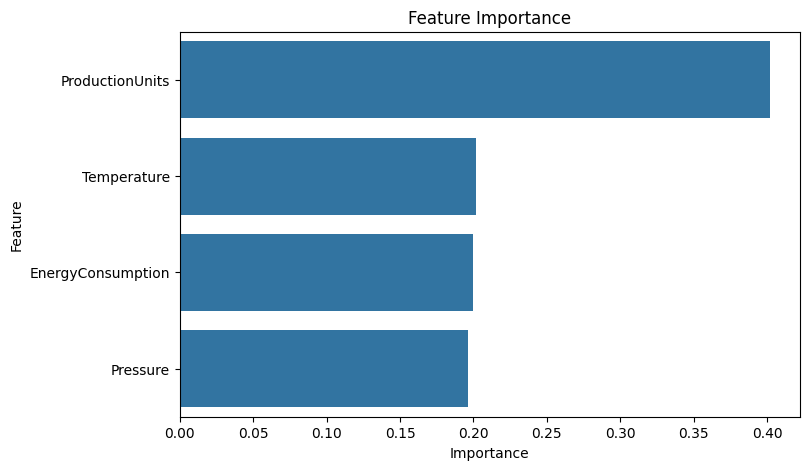

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()


## 📊 Insights

Based on feature importance:

- Features with higher importance have stronger impact on defects
- For example:
  - High importance of Temperature → defects increase with temperature variation
  - High importance of EnergyConsumption → inefficient energy usage may cause defects
  - Low importance features have minimal effect

## 📌 Key Observations:
- Machine conditions directly influence product quality
- Some variables contribute more significantly to defect generation
- ProductionUnits helps normalize defect behavior

## 🧠 Business Insights:
- Focus on controlling high-impact variables
- Monitor machines with abnormal readings
- Optimize energy usage to reduce defects